# Generating transformers

In [1]:
from sklearn.base import BaseEstimator, TransformerMixin
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline

import matplotlib.pyplot as plt

In [ ]:
# 1️⃣ Regularity Resampling Transformer
class RegularityResampler(BaseEstimator, TransformerMixin):
    def __init__(self, freq='1H'):
        self.freq = freq  # Resampling frequency

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()

        # Ensure unique timestamps per ProcessId
        X = X.drop_duplicates(subset=['ProcessId', 'DateTime'], keep='last')

        # Sort by ProcessId and DateTime
        X = X.sort_values(by=['ProcessId', 'DateTime'])

        # Resampling process
        resampled_dfs = []
        for process_id, group in X.groupby("ProcessId"):
            # Create a full time index for this process
            full_index = pd.date_range(start=group["DateTime"].min(),
                                       end=group["DateTime"].max(),
                                       freq=self.freq)
            full_index = pd.MultiIndex.from_product([[process_id], full_index],
                                                    names=["ProcessId", "DateTime"])

            # Set index, reindex to fill missing timestamps
            group = group.set_index(["ProcessId", "DateTime"]).reindex(full_index)

            # Interpolate missing values (optional)
            numeric_cols = group.select_dtypes(include=[float, int]).columns
            group[numeric_cols] = group[numeric_cols].interpolate()

            resampled_dfs.append(group)

        return pd.concat(resampled_dfs).reset_index()

# 2️⃣ Imputation Transformers
class NAInterpolator(BaseEstimator, TransformerMixin):
    def __init__(self, method='linear'):
        self.method = method

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        return X.interpolate(method=self.method)

class NAForwardFill(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        return X.ffill()

class NABackwardFill(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        return X.bfill()

# 3️⃣ Feature Extraction - Lag Features
class LagFeatureExtractor(BaseEstimator, TransformerMixin):
    def __init__(self, n_lags=2, target_col='event'):
        self.n_lags = n_lags  # Number of past values to consider
        self.target_col = target_col  # Column to predict, which should be excluded

    def fit(self, X, y=None):
        return self  # No fitting required

    def transform(self, X):
        X = X.copy()  # Avoid modifying the original data
        X.sort_values(by=['ProcessId', 'DateTime'], inplace=True)

        # Select numeric columns only, EXCLUDING ProcessId, DateTime, and the target variable
        exclude_cols = {'ProcessId', 'DateTime', self.target_col}
        numeric_cols = [col for col in X.select_dtypes(include=[np.number]).columns if col not in exclude_cols]

        # Create a DataFrame to store lag features
        lagged_data = []

        for process_id, group in X.groupby('ProcessId'):
            group = group.sort_values(by='DateTime').copy()

            # Compute rolling mean for numeric columns (excluding the target variable)
            lagged_features = group[numeric_cols].shift(1).rolling(window=self.n_lags, min_periods=1).mean()

            # Prefix column names for clarity
            lagged_features.columns = [f"{col}_lag_mean_{self.n_lags}" for col in lagged_features.columns]

            # Concatenate back with the original group
            group = pd.concat([group, lagged_features], axis=1)

            # Drop first `n_lags` rows *for this process_id only*
            group = group.iloc[self.n_lags:]

            lagged_data.append(group)

        # Concatenate processed groups
        X_transformed = pd.concat(lagged_data).reset_index(drop=True)

        return X_transformed

# 4️⃣ Feature Selection - Correlation
class CorrelationFeatureSelector(BaseEstimator, TransformerMixin):
    def __init__(self, threshold=0.9):
        self.threshold = threshold
        self.drop_features = []

    def fit(self, X, y=None):
        corr_matrix = X.corr().abs()
        upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
        self.drop_features = [col for col in upper_tri.columns if any(upper_tri[col] > self.threshold)]
        return self

    def transform(self, X):
        return X.drop(columns=self.drop_features)

# 5️⃣ Feature Selection - PCA
class PCAFeatureSelector(BaseEstimator, TransformerMixin):
    def __init__(self, variance_threshold=0.95, exclude_cols=None):
        self.variance_threshold = variance_threshold
        self.exclude_cols = exclude_cols if exclude_cols is not None else ['ProcessId', 'DateTime', 'event']
        self.pca = None  # PCA model will be fitted during `fit`
        self.num_components = None  # Number of components to retain

    def fit(self, X, y=None):
        # Select numeric columns while excluding non-relevant ones
        feature_cols = [col for col in X.select_dtypes(include=[np.number]).columns if col not in self.exclude_cols]
        X_numeric = X[feature_cols]

        # Fit PCA to capture variance
        self.pca = PCA()
        self.pca.fit(X_numeric)
        explained_variance_ratio = np.cumsum(self.pca.explained_variance_ratio_)

        # Determine number of components to retain
        self.num_components = np.argmax(explained_variance_ratio >= self.variance_threshold) + 1
        print(f"Selected {self.num_components} PCA components to explain {self.variance_threshold * 100}% variance")

        return self

    def transform(self, X):
        X = X.copy()
        feature_cols = [col for col in X.select_dtypes(include=[np.number]).columns if col not in self.exclude_cols]
        X_numeric = X[feature_cols]

        # Apply PCA transformation
        X_pca = self.pca.transform(X_numeric)[:, :self.num_components]

        # Convert to DataFrame with meaningful column names
        pca_cols = [f'PC{i+1}' for i in range(self.num_components)]
        X_pca_df = pd.DataFrame(X_pca, columns=pca_cols, index=X.index)

        # Concatenate back with the excluded columns
        X_transformed = pd.concat([X[self.exclude_cols], X_pca_df], axis=1)

        return X_transformed



# Testing transformers

In [ ]:
# Load dataset
df = pd.read_pickle("Datasets/final_dataset.pkl")

# Sort to ensure correct time order
df.sort_values(by=["ProcessId", "DateTime"], inplace=True)

df.head()


,ProcessId,DateTime,TPressHardSample1,TPressHardSample2,TPressHardSample3,TPressHardSample4,TPressHardSample5,TPressHardSample6,TPressHardSample7,TPressHardSample8,...,TPressSetupCode_164,TPressSetupCode_165,TPressSetupCode_170,TPressSetupCode_174,TPressSetupCode_185,TPressSetupCode_186,TPressSettingsObject,EventObject,EventCode,event
0,207357,2022-01-10 12:16:55,167.0,166.0,171.0,175.0,156.0,152.0,142.0,151.0,...,600.0,0.0,0.0,0.0,0.0,0.0,1580.0,1580.0,5194.0,0
1,207357,2022-01-10 12:19:57,163.0,153.0,147.0,149.0,167.0,153.0,172.0,149.0,...,600.0,0.0,0.0,0.0,0.0,0.0,1580.0,1580.0,5194.0,0
2,207357,2022-01-10 12:50:35,145.0,156.0,147.0,158.0,150.0,152.0,156.0,164.0,...,600.0,0.0,0.0,0.0,0.0,0.0,1580.0,1580.0,5194.0,0
3,207357,2022-01-10 12:52:00,145.0,156.0,147.0,158.0,150.0,152.0,156.0,164.0,...,600.0,0.0,0.0,0.0,0.0,0.0,1580.0,1580.0,5194.0,0
4,207357,2022-01-10 14:02:21,147.0,149.0,147.0,163.0,165.0,174.0,149.0,151.0,...,600.0,0.0,0.0,0.0,0.0,0.0,1580.0,1580.0,5194.0,0


## Test resampling transformer

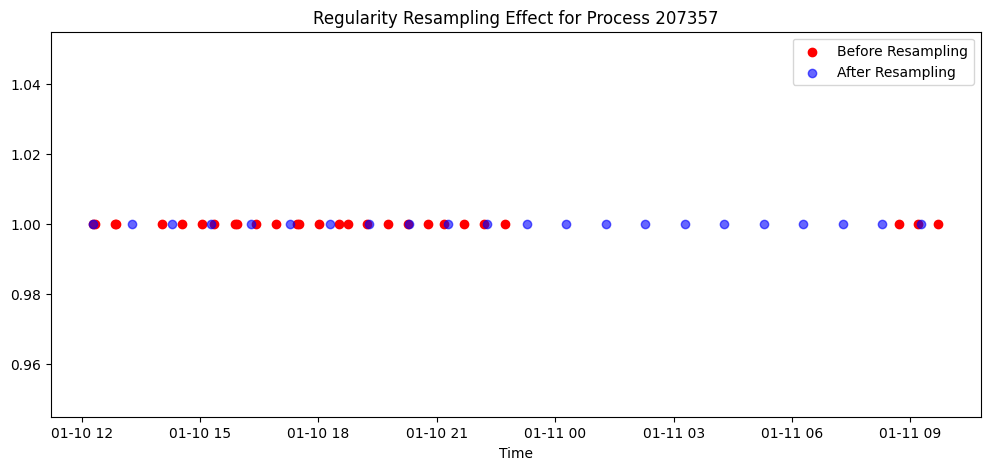

In [ ]:
# Apply Regularity Resampler
pipeline = Pipeline([
    ('regularity', RegularityResampler(freq='1H'))
])

df_resampled = pipeline.fit_transform(df)

# Plot to compare before & after
process_id = df["ProcessId"].unique()[0]  # Pick one process for clarity
df_before = df[df["ProcessId"] == process_id]
df_after = df_resampled[df_resampled["ProcessId"] == process_id]

plt.figure(figsize=(12, 5))
plt.scatter(df_before["DateTime"], [1] * len(df_before), label="Before Resampling", color='red')
plt.scatter(df_after["DateTime"], [1] * len(df_after), label="After Resampling", color='blue', alpha=0.6)
plt.xlabel("Time")
plt.legend()
plt.title(f"Regularity Resampling Effect for Process {process_id}")
plt.show()


## Testing Imputation transformers

In [9]:
pipeline = Pipeline([
    ('imputation', NAInterpolator(method='linear'))
])

df_imputed = pipeline.fit_transform(df)
df_imputed.head()

,ProcessId,DateTime,TPressHardSample1,TPressHardSample2,TPressHardSample3,TPressHardSample4,TPressHardSample5,TPressHardSample6,TPressHardSample7,TPressHardSample8,...,TPressSetupCode_164,TPressSetupCode_165,TPressSetupCode_170,TPressSetupCode_174,TPressSetupCode_185,TPressSetupCode_186,TPressSettingsObject,EventObject,EventCode,event
0,207357,2022-01-10 12:16:55,167.0,166.0,171.0,175.0,156.0,152.0,142.0,151.0,...,600.0,0.0,0.0,0.0,0.0,0.0,1580.0,1580.0,5194.0,0
1,207357,2022-01-10 12:19:57,163.0,153.0,147.0,149.0,167.0,153.0,172.0,149.0,...,600.0,0.0,0.0,0.0,0.0,0.0,1580.0,1580.0,5194.0,0
2,207357,2022-01-10 12:50:35,145.0,156.0,147.0,158.0,150.0,152.0,156.0,164.0,...,600.0,0.0,0.0,0.0,0.0,0.0,1580.0,1580.0,5194.0,0
3,207357,2022-01-10 12:52:00,145.0,156.0,147.0,158.0,150.0,152.0,156.0,164.0,...,600.0,0.0,0.0,0.0,0.0,0.0,1580.0,1580.0,5194.0,0
4,207357,2022-01-10 14:02:21,147.0,149.0,147.0,163.0,165.0,174.0,149.0,151.0,...,600.0,0.0,0.0,0.0,0.0,0.0,1580.0,1580.0,5194.0,0


## Testing lag_based_features transformer

In [25]:
pipeline = Pipeline([
    ('lag_features', LagFeatureExtractor(n_lags=3))
])

df_lagged = pipeline.fit_transform(df)

df_lagged.head()

,ProcessId,DateTime,TPressHardSample1,TPressHardSample2,TPressHardSample3,TPressHardSample4,TPressHardSample5,TPressHardSample6,TPressHardSample7,TPressHardSample8,...,TPressSetupCode_163_lag_mean_3,TPressSetupCode_164_lag_mean_3,TPressSetupCode_165_lag_mean_3,TPressSetupCode_170_lag_mean_3,TPressSetupCode_174_lag_mean_3,TPressSetupCode_185_lag_mean_3,TPressSetupCode_186_lag_mean_3,TPressSettingsObject_lag_mean_3,EventObject_lag_mean_3,EventCode_lag_mean_3
0,207357,2022-01-10 12:52:00,145.0,156.0,147.0,158.0,150.0,152.0,156.0,164.0,...,0.0,600.0,0.0,0.0,0.0,0.0,0.0,1580.0,1580.0,5194.0
1,207357,2022-01-10 14:02:21,147.0,149.0,147.0,163.0,165.0,174.0,149.0,151.0,...,0.0,600.0,0.0,0.0,0.0,0.0,0.0,1580.0,1580.0,5194.0
2,207357,2022-01-10 14:32:18,151.0,165.0,152.0,144.0,161.0,155.0,156.0,159.0,...,0.0,600.0,0.0,0.0,0.0,0.0,0.0,1580.0,1580.0,5194.0
3,207357,2022-01-10 15:02:48,171.0,139.0,147.0,151.0,158.0,145.0,154.0,158.0,...,0.0,600.0,0.0,0.0,0.0,0.0,0.0,1580.0,1580.0,5194.0
4,207357,2022-01-10 15:21:52,159.0,148.0,149.0,163.0,144.0,161.0,161.0,155.0,...,0.0,600.0,0.0,0.0,0.0,0.0,0.0,1580.0,1580.0,5194.0


## Testing correlation transformer

In [26]:
pipeline = Pipeline([
    ('feature_selection', CorrelationFeatureSelector(threshold=0.9))
])

df_selected = pipeline.fit_transform(df)

print("Remaining features after correlation filter:", df_selected.columns)


Remaining features after correlation filter: Index(['ProcessId', 'TPressHardSample1', 'TPressThickSample1',
       'TPressWeightSample11', 'Object', 'TPressProdReportFCCPVM',
       'TPressProdReportFCSrel', 'TPressProdReportFCPCVM',
       'TPressProdReportThickSrel', 'TPressProdReportHardSrel',
       ...
       'TPressSetupCode_128', 'TPressSetupCode_139', 'TPressSetupCode_163',
       'TPressSetupCode_164', 'TPressSetupCode_165', 'TPressSetupCode_170',
       'TPressSetupCode_174', 'TPressSetupCode_185', 'EventCode', 'event'],
      dtype='object', length=134)


## Testing PCA transformer

In [29]:
pipeline = Pipeline([
    ('pca', PCAFeatureSelector(variance_threshold=0.95))
])

df_pca = pipeline.fit_transform(df)

print(df_pca.head(10))

Selected 2 PCA components to explain 95.0% variance
   ProcessId            DateTime  event            PC1            PC2
0     207357 2022-01-10 12:16:55      0 -569152.847006  185655.686798
1     207357 2022-01-10 12:19:57      0 -567500.321191  184198.850327
2     207357 2022-01-10 12:50:35      0 -550249.803095  168991.053248
3     207357 2022-01-10 12:52:00      0 -633570.049232   74476.207963
4     207357 2022-01-10 14:02:21      0 -627048.532663   68726.921932
5     207357 2022-01-10 14:32:18      0 -610242.838807   53911.273748
6     207357 2022-01-10 15:02:48      0 -593141.626692   38835.086327
7     207357 2022-01-10 15:21:52      1 -582458.415078   29416.926414
8     207357 2022-01-10 15:52:32      0 -565659.484626   14607.234507
9     207357 2022-01-10 15:55:38      0 -563856.195646   13017.481864
